In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [42]:
# 1. 데이터 로딩 및 파생변수 생성
url = "https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## K-means

### Cell 1: 데이터 로드

In [43]:
df.columns = df.columns.str.strip()
df.rename(columns={'Temperature_T0': 'Temperature_J0'}, inplace=True)
df_clean = df.dropna().copy()

# 2. 파생 변수 생성
current_cols = [f'Current_J{i}' for i in range(6)]
speed_cols = [f'Speed_J{i}' for i in range(6)]
temp_cols = [f'Temperature_J{i}' for i in range(6)]

for i in range(6):
    df_clean[f'Power_J{i}'] = df_clean[f'Current_J{i}'] * df_clean[f'Speed_J{i}']
df_clean['Total_Power_Electric'] = (df_clean[current_cols]**2).sum(axis=1)

# 2. 군집화용 피처 설정
#cluster_cols = current_cols + speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
#cluster_cols = current_cols #+ speed_cols + temp_cols + ['Tool_current'] + [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric']
cluster_cols = [f'Power_J{i}' for i in range(6)] + ['Total_Power_Electric'] + ['Tool_current']
X_cluster = df_clean[cluster_cols]

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"군집화에 사용된 피처 개수: {len(cluster_cols)}개")

군집화에 사용된 피처 개수: 8개


### Cell 2: 최적의 K 찾기 (Elbow Method & Silhouette Score)

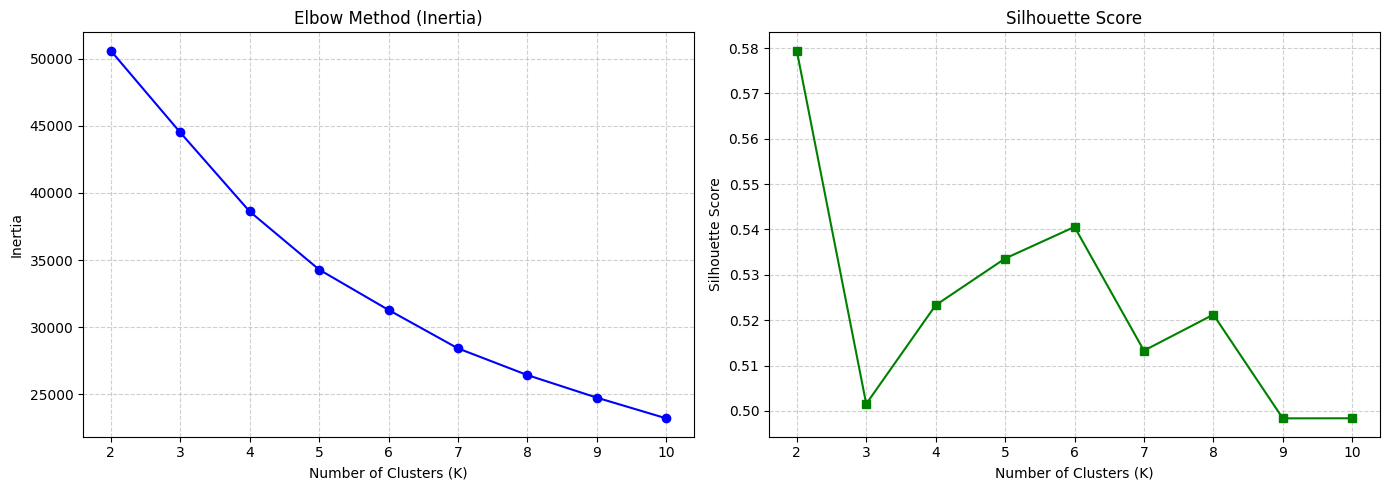


[K값별 실루엣 점수]
  K= 2 → Silhouette = 0.5794
  K= 3 → Silhouette = 0.5016
  K= 4 → Silhouette = 0.5233
  K= 5 → Silhouette = 0.5336
  K= 6 → Silhouette = 0.5406
  K= 7 → Silhouette = 0.5133
  K= 8 → Silhouette = 0.5212
  K= 9 → Silhouette = 0.4984
  K=10 → Silhouette = 0.4984


In [44]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method (Inertia)
axes[0].plot(K_range, inertia, marker='o', linestyle='-', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Silhouette Score
axes[1].plot(K_range, sil_scores, marker='s', linestyle='-', color='g')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
# 결과 요약 출력
print("\n[K값별 실루엣 점수]")
for k, s in zip(K_range, sil_scores):
    print(f"  K={k:2d} → Silhouette = {s:.4f}")

### Cell 3: K=3 으로 최종 군집화 및 결과 매핑

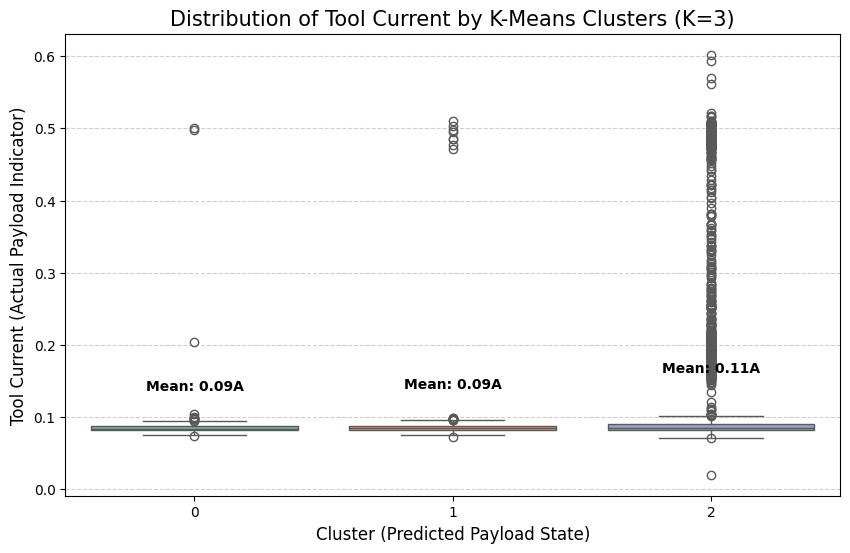


[가장 중요한 결과 해석]
이 박스플롯이 완벽하게 3단계의 계단 형태를 띠고 서로 겹치지 않는다면, 
우리의 K-Means 모델은 'Tool_current'를 전혀 보지 않고도 오직 관절들의 움직임 패턴만으로 
로봇이 1kg, 2kg, 3kg 중 어떤 하중을 들고 있는지 완벽하게 역추적(Reverse Engineering)해 낸 것입니다!



In [45]:
# K=3으로 최종 학습
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 군집 번호를 하중이 작은 순서대로(0, 1, 2) 예쁘게 재정렬하기 위한 작업
cluster_mapping = df_clean.groupby('Cluster')['Tool_current'].mean().sort_values().index
remap_dict = {old_id: new_id for new_id, old_id in enumerate(cluster_mapping)}
df_clean['Cluster'] = df_clean['Cluster'].map(remap_dict)

# 시각화 검증
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Tool_current', data=df_clean, palette='Set2')
plt.title('Distribution of Tool Current by K-Means Clusters (K=3)', fontsize=15)
plt.xlabel('Cluster (Predicted Payload State)', fontsize=12)
plt.ylabel('Tool Current (Actual Payload Indicator)', fontsize=12)

# 각 군집별 Tool_current 평균값 표시
means = df_clean.groupby('Cluster')['Tool_current'].mean()
for i, mean_val in enumerate(means):
    plt.text(i, mean_val + 0.05, f'Mean: {mean_val:.2f}A', ha='center', fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("""
[가장 중요한 결과 해석]
이 박스플롯이 완벽하게 3단계의 계단 형태를 띠고 서로 겹치지 않는다면, 
우리의 K-Means 모델은 'Tool_current'를 전혀 보지 않고도 오직 관절들의 움직임 패턴만으로 
로봇이 1kg, 2kg, 3kg 중 어떤 하중을 들고 있는지 완벽하게 역추적(Reverse Engineering)해 낸 것입니다!
""")

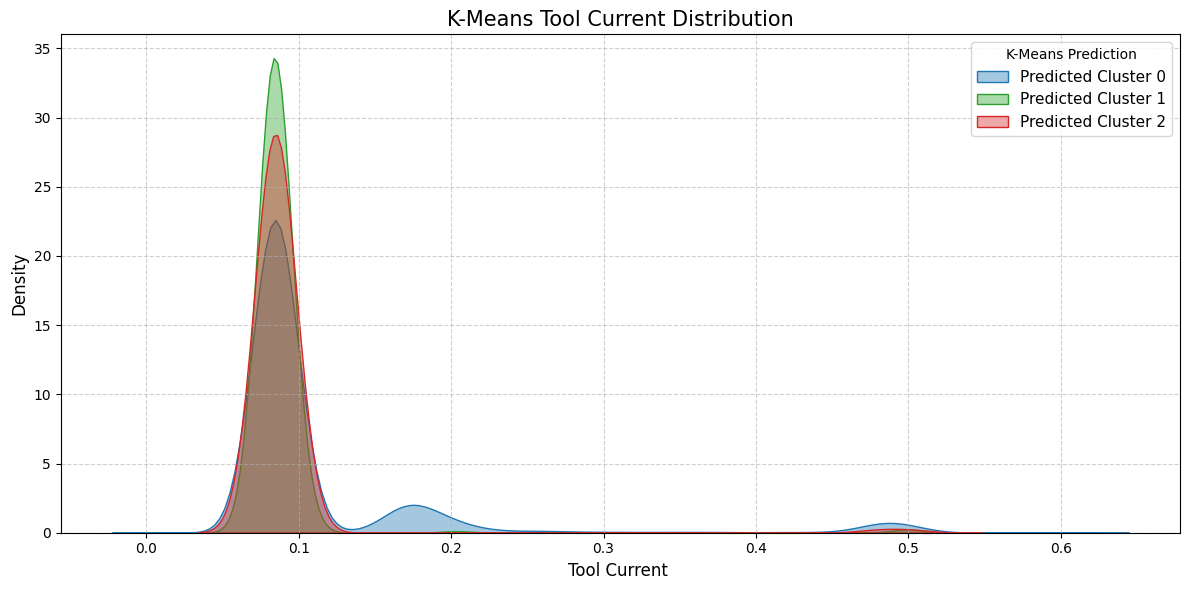


[새로운 그래프 해석 방법]
- 만약 군집화가 잘 되었다면: 파란산, 초록산, 빨간산이 좌우로 예쁘게 3개로 떨어져 있어야 합니다.
- 지금 멸망(?)한 이 그래프를 보시면: 색깔이 다른 3개의 산이 완전히 똑같은 위치(특히 0.08 부근)에 
  마구잡이로 겹쳐서 솟아 있을 것입니다.
- 결론: K-Means는 하중(Tool Current) 기준으로는 데이터를 전혀 분류해 내지 못했다는 완벽한 증거입니다!



In [46]:
# K=3으로 최종 학습
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(12, 6))

# 군집별로 색상을 다르게 하여 겹쳐 그리기
colors = ['#1f77b4', '#2ca02c', '#d62728'] # 파랑, 초록, 빨강
for cluster_id, color in zip(sorted(df_clean['Cluster'].unique()), colors):
    sns.kdeplot(
        data=df_clean[df_clean['Cluster'] == cluster_id], 
        x='Tool_current', 
        fill=True, 
        color=color,
        alpha=0.4,
        label=f'Predicted Cluster {cluster_id}'
    )

plt.title('K-Means Tool Current Distribution', fontsize=15)
plt.xlabel('Tool Current ', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='K-Means Prediction', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
[새로운 그래프 해석 방법]
- 만약 군집화가 잘 되었다면: 파란산, 초록산, 빨간산이 좌우로 예쁘게 3개로 떨어져 있어야 합니다.
- 지금 멸망(?)한 이 그래프를 보시면: 색깔이 다른 3개의 산이 완전히 똑같은 위치(특히 0.08 부근)에 
  마구잡이로 겹쳐서 솟아 있을 것입니다.
- 결론: K-Means는 하중(Tool Current) 기준으로는 데이터를 전혀 분류해 내지 못했다는 완벽한 증거입니다!
""")